In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
from pathlib import Path


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:

data_dir = Path(path) / "chest_xray"
img_size = (224,224)
batch_size = 32


In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir / "train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir / "val",
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir / "test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary',
    shuffle=False   # important for evaluation
)



Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


Inbalence Dataset

In [5]:
import os

# Function to count images in each class folder
def count_images_in_dir(directory):
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

# Train
train_counts = count_images_in_dir(data_dir / "train")
val_counts = count_images_in_dir(data_dir / "val")
test_counts = count_images_in_dir(data_dir / "test")

print("Train set counts:", train_counts)
print("Validation set counts:", val_counts)
print("Test set counts:", test_counts)


Train set counts: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Validation set counts: {'PNEUMONIA': 8, 'NORMAL': 8}
Test set counts: {'PNEUMONIA': 390, 'NORMAL': 234}


val_ds is too small, so i will split train_ds

In [6]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir / "train",
    validation_split=0.15,       # 15% for validation
    subset="training",
    seed=123,                    # Seed for reproducibility
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'          # for binary classification
)

# Validation dataset (15% of training data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir / "train",
    validation_split=0.15,
    subset="validation",
    seed=123,                    # same seed!
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)


Found 5216 files belonging to 2 classes.
Using 4434 files for training.
Found 5216 files belonging to 2 classes.
Using 782 files for validation.


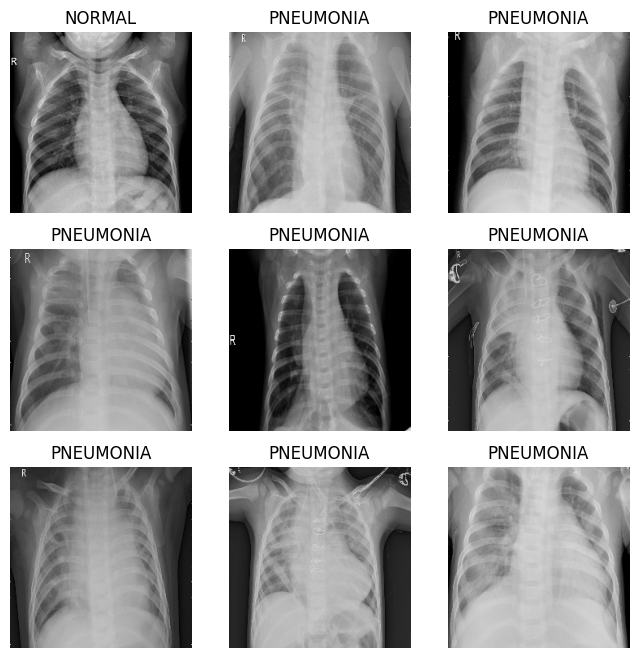

In [7]:
import matplotlib.pyplot as plt

# Get one batch of images and labels from the training dataset
image_batch, label_batch = next(iter(train_ds))

class_names = ['NORMAL', 'PNEUMONIA']  # Your classes

plt.figure(figsize=(8, 8))

for i in range(9):  # Show 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    label = class_names[int(label_batch[i])]
    plt.title(label)
    plt.axis("off")

plt.show()


In [8]:
for images, labels in train_ds.take(1):  # Take one batch
    print("Batch image shape:", images.shape)  # (batch_size, height, width, channels)
    print("Single image shape:", images[0].shape)  # (height, width, channels)


Batch image shape: (32, 224, 224, 3)
Single image shape: (224, 224, 3)


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)


AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Extract all training labels into a flat NumPy array
y_train = np.concatenate([y.numpy() for x, y in train_ds.unbatch()])

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.916162489196197), 1: np.float64(0.6765334147085749)}


In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),

])

In [12]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])



In [13]:
model.compile(
    optimizer='Adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 542s 4s/step - accuracy: 0.4728 - auc: 0.5661 - loss: 0.9776 - val_accuracy: 0.6765 - val_auc: 0.8333 - val_loss: 0.6214
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 564s 4s/step - accuracy: 0.7287 - auc: 0.8159 - loss: 0.5394 - val_accuracy: 0.8875 - val_auc: 0.9692 - val_loss: 0.2874
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 574s 4s/step - accuracy: 0.8212 - auc: 0.9048 - loss: 0.3871 - val_accuracy: 0.9335 - val_auc: 0.9876 - val_loss: 0.1814
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 540s 4s/step - accuracy: 0.8837 - auc: 0.9516 - loss: 0.2820 - val_accuracy: 0.9322 - val_auc: 0.9893 - val_loss: 0.1634
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 528s 4s/step - accuracy: 0.9031 - auc: 0.9654 - loss: 0.2380 - val_accuracy: 0.9578 - val_auc: 0.9876 - val_loss: 0.1227
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 577s 4s/step - accuracy: 0.9029 - auc: 0.9636 - loss: 0.2491 - val_accuracy: 0.9348 - val_auc: 0.9910 - val_loss: 0.1655
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━

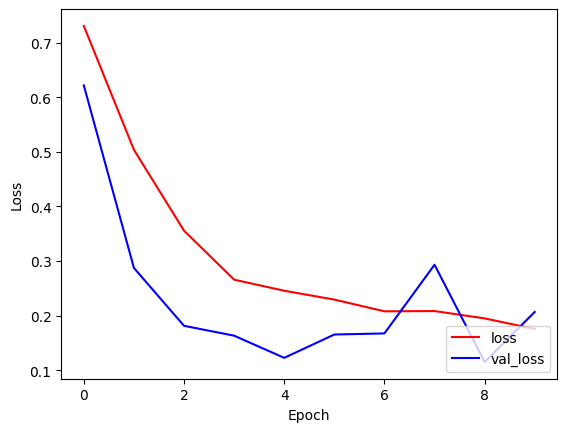

In [14]:
#TODO: Plot Loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='r', label='loss')
plt.plot(history.history['val_loss'] ,color='b', label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

plt.show()

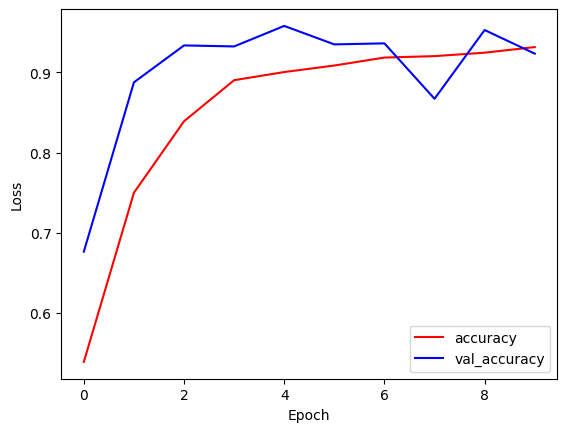

In [15]:
#TODO: Plot accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='r', label='accuracy')
plt.plot(history.history['val_accuracy'] ,color='b', label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

plt.show()

In [16]:

y_true = []
y_pred = []

for images, labels in test_ds:
    # Predict probabilities
    preds = model.predict(images)
    # Convert probabilities to binary class (0 or 1)
    predicted_classes = (preds > 0.5).astype("int32")

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 958ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 972ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 925ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 886ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 894ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Optional: Show classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))


Confusion Matrix:
[[182  52]
 [ 23 367]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.78      0.83       234
   PNEUMONIA       0.88      0.94      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624



**MobileNetV2**

In [18]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir / "train",
    validation_split=0.15,       # 15% for validation
    subset="training",
    seed=123,                    # Seed for reproducibility
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'          # for binary classification
)

# Validation dataset (15% of training data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir / "train",
    validation_split=0.15,
    subset="validation",
    seed=123,                    # same seed!
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir / "test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary',
    shuffle=False   # important for evaluation
)

Found 5216 files belonging to 2 classes.
Using 4434 files for training.
Found 5216 files belonging to 2 classes.
Using 782 files for validation.
Found 624 files belonging to 2 classes.


In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Extract labels from training dataset (flattened)
y_train = np.concatenate([y.numpy() for x, y in train_ds.unbatch()])

# Compute class weights automatically (for classes 0 and 1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0,1]), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

print("Class weights:", class_weights_dict)


Class weights: {0: np.float64(1.916162489196197), 1: np.float64(0.6765334147085749)}


In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),

])

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Parameters
img_size = (224, 224)
batch_size = 32


train_ds = train_ds.map(lambda x, y: (preprocess_input(data_augmentation(x, training=True)), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)



In [22]:
# Load MobileNetV2 base model, pretrained on ImageNet, excluding top layers
base_model = MobileNetV2(input_shape=img_size + (3,),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model initially
base_model.trainable = False

# Build the full model
inputs = layers.Input(shape=img_size + (3,))
x = base_model(inputs, training=False)  # Use base_model in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)  # Dropout for regularization
outputs = layers.Dense(1, activation='sigmoid')(x)  # sigmoid for binary

model = models.Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

model.summary()

# Train the model (example)
history = model.fit(train_ds,
                    validation_data=val_ds,
                    class_weight=class_weights_dict,
                    epochs=10)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.7216 - loss: 0.5346 - precision: 0.8717 - recall: 0.7383 - val_accuracy: 0.9297 - val_loss: 0.1911 - val_precision: 0.9429 - val_recall: 0.9666
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.9026 - loss: 0.2419 - precision: 0.9707 - recall: 0.8962 - val_accuracy: 0.9425 - val_loss: 0.1541 - val_precision: 0.9726 - val_recall: 0.9515
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.9166 - loss: 0.2096 - precision: 0.9721 - recall: 0.9149 - val_accuracy: 0.9463 - val_loss: 0.1425 - val_precision: 0.9793 - val_recall: 0.9498
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.9228 - loss: 0.1893 - precision: 0.9748 - recall: 0.9205 - val_accuracy: 0.9463 - val_loss: 0.1433 - val_precision: 0.9843 - val_recall: 0.9448
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9252 - loss: 0.1765 - precision: 0.9778 - recall: 0.9212 - val_accuracy: 0.9565 - val_los

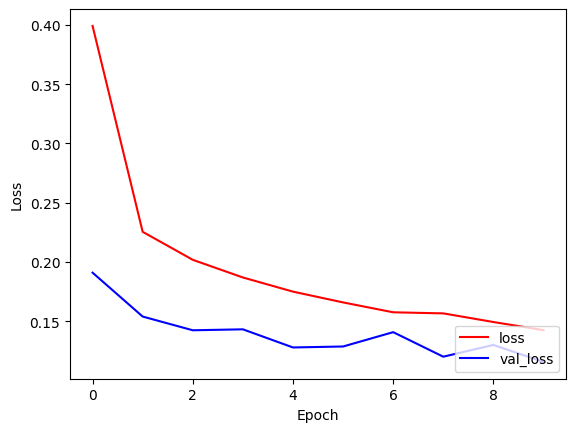

In [23]:
#TODO: Plot Loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='r', label='loss')
plt.plot(history.history['val_loss'] ,color='b', label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

plt.show()

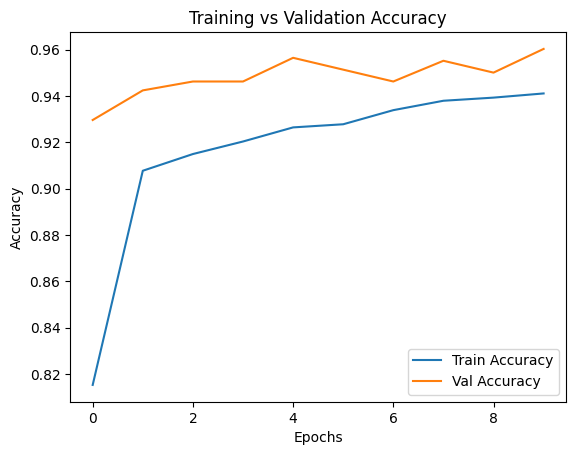

In [24]:
# 9. Plot Training
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()



In [25]:
# Get true labels and predicted probabilities
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities to binary predictions using 0.5 threshold
y_pred = (y_pred_probs >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report (precision, recall, f1-score)
report = classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'])
print("Classification Report:")
print(report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Confusion Matrix:
[[132 102]
 [  6 384]]
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.56      0.71       234
   PNEUMONIA       0.79      0.98      0.88       390

    accuracy                           0.83       62

In [26]:
base_model.trainable = True

# Freeze all layers except the last N (e.g., last 30)
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

history_finetune = model.fit(train_ds,
                             validation_data=val_ds,
                             class_weight=class_weights_dict,
                             epochs=10)


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.8978 - loss: 0.3685 - precision_1: 0.9191 - recall_1: 0.9469 - val_accuracy: 0.9629 - val_loss: 0.1087 - val_precision_1: 0.9798 - val_recall_1: 0.9716
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.9235 - loss: 0.1871 - precision_1: 0.9794 - recall_1: 0.9174 - val_accuracy: 0.9616 - val_loss: 0.1055 - val_precision_1: 0.9830 - val_recall_1: 0.9666
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.9338 - loss: 0.1540 - precision_1: 0.9834 - recall_1: 0.9273 - val_accuracy: 0.9629 - val_loss: 0.1048 - val_precision_1: 0.9880 - val_recall_1: 0.9632
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.9354 - loss: 0.1553 - precision_1: 0.9856 - recall_1: 0.9278 - val_accuracy: 0.9604 - val_loss: 0.1116 - val_precision_1: 0.9880 - val_recall_1: 0.9599
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9412 - loss: 0.1367 - precision_1: 0.9830 - recall_1: 0.9

In [27]:
# Get true labels and predicted probabilities
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities to binary predictions using 0.5 threshold
y_pred = (y_pred_probs >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report (precision, recall, f1-score)
report = classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'])
print("Classification Report:")
print(report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Confusion Matrix:
[[190  44]
 [ 14 376]]
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.81      0.87       234
   PNEUMONIA       0.90      0.96      0.93       390

    accuracy                           0.91       62